In [2]:
from pathlib import Path
import sys

%load_ext autoreload
%autoreload 2

dir = Path().resolve().parents[1]

if dir not in sys.path:
  sys.path.append(str(dir))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import yfinance as yf
import math
from utils import log_transform
import torch
import joblib
from utils import one_step_rolling_forecast
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

In [4]:
ticker = "^GSPC"
start_interval = "2010-01-01"
end_interval = "2026-01-01"
interval = "1d" 

raw_snp500 = yf.Ticker(ticker).history(start=start_interval, end=end_interval, interval=interval)["Close"].to_numpy()
split = math.ceil(len(raw_snp500) * 0.2)
val_split = len(raw_snp500) - split * 2
test_split = len(raw_snp500) - split

train_raw_snp500, val_raw_snp500, test_raw_snp500 = raw_snp500[:val_split], raw_snp500[val_split:test_split], raw_snp500[test_split:]

train_snp500 = log_transform(train_raw_snp500)
test_snp500 = log_transform(test_raw_snp500)

In [5]:
SYN_PATH_128 = dir / "data" / "syn_data_128.joblib"
SYN_PATH_256 = dir / "data" / "syn_data_256.joblib"
SYN_PATH_512 = dir / "data" / "syn_data_512.joblib"

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
torch.cuda.manual_seed(42)
device

'cpu'

In [6]:
synthetic_data_128 = joblib.load(SYN_PATH_128)
synthetic_data_256 = joblib.load(SYN_PATH_256)
synthetic_data_512 = joblib.load(SYN_PATH_512)

synthetic_data_128.shape, synthetic_data_256.shape, synthetic_data_512.shape

((32, 128), (32, 256), (32, 512))

### DDPM Simulation Testing

In [32]:
latest_emp_window_128 = train_snp500[-128:]
test_window_128 = test_snp500[:128]

latest_emp_window_256 = train_snp500[-256:]
test_window_256 = test_snp500[:256]

latest_emp_window_512 = train_snp500[-512:]
test_window_512 = test_snp500[:512]

In [33]:
# 128-window
syn_preds_windows_128 = []
syn_losses_windows_128 = []

for syn_window in synthetic_data_128:
  syn_preds, losses = one_step_rolling_forecast(latest_emp_window_128 * 100, syn_window * 100) # scaling for stabilization in GARCH fitting
  syn_preds_windows_128.append(syn_preds)
  syn_losses_windows_128.append(losses)

emp_preds_128, emp_losses_128 = one_step_rolling_forecast(latest_emp_window_128 * 100, test_window_128 * 100)

In [34]:
# scaled back
syn_preds_windows_128 = np.array(syn_preds_windows_128) / 100
emp_preds_128 = np.array(emp_preds_128) / 100

In [35]:
# 256-window
syn_preds_windows_256 = []
syn_losses_windows_256 = []

for syn_window in synthetic_data_256:
  syn_preds, losses = one_step_rolling_forecast(latest_emp_window_256 * 100, syn_window * 100) # scaling for stabilization in GARCH fitting
  syn_preds_windows_256.append(syn_preds)
  syn_losses_windows_256.append(losses)

emp_preds_256, emp_losses_256 = one_step_rolling_forecast(latest_emp_window_256 * 100, test_window_256 * 100)

In [36]:
# scaled back
syn_preds_windows_256 = np.array(syn_preds_windows_256) / 100
emp_preds_256 = np.array(emp_preds_256) / 100

In [37]:
# 512-window
syn_preds_windows_512 = []
syn_losses_windows_512 = []

for syn_window in synthetic_data_512:
  syn_preds, losses = one_step_rolling_forecast(latest_emp_window_512 * 100, syn_window * 100) # scaling for stabilization in GARCH fitting
  syn_preds_windows_512.append(syn_preds)
  syn_losses_windows_512.append(losses)

emp_preds_512, emp_losses_512 = one_step_rolling_forecast(latest_emp_window_512 * 100, test_window_512 * 100)

In [38]:
# scaled back
syn_preds_windows_512 = np.array(syn_preds_windows_512) / 100
emp_preds_512 = np.array(emp_preds_512) / 100

In [39]:
syn_preds_windows_512.shape

(32, 512)

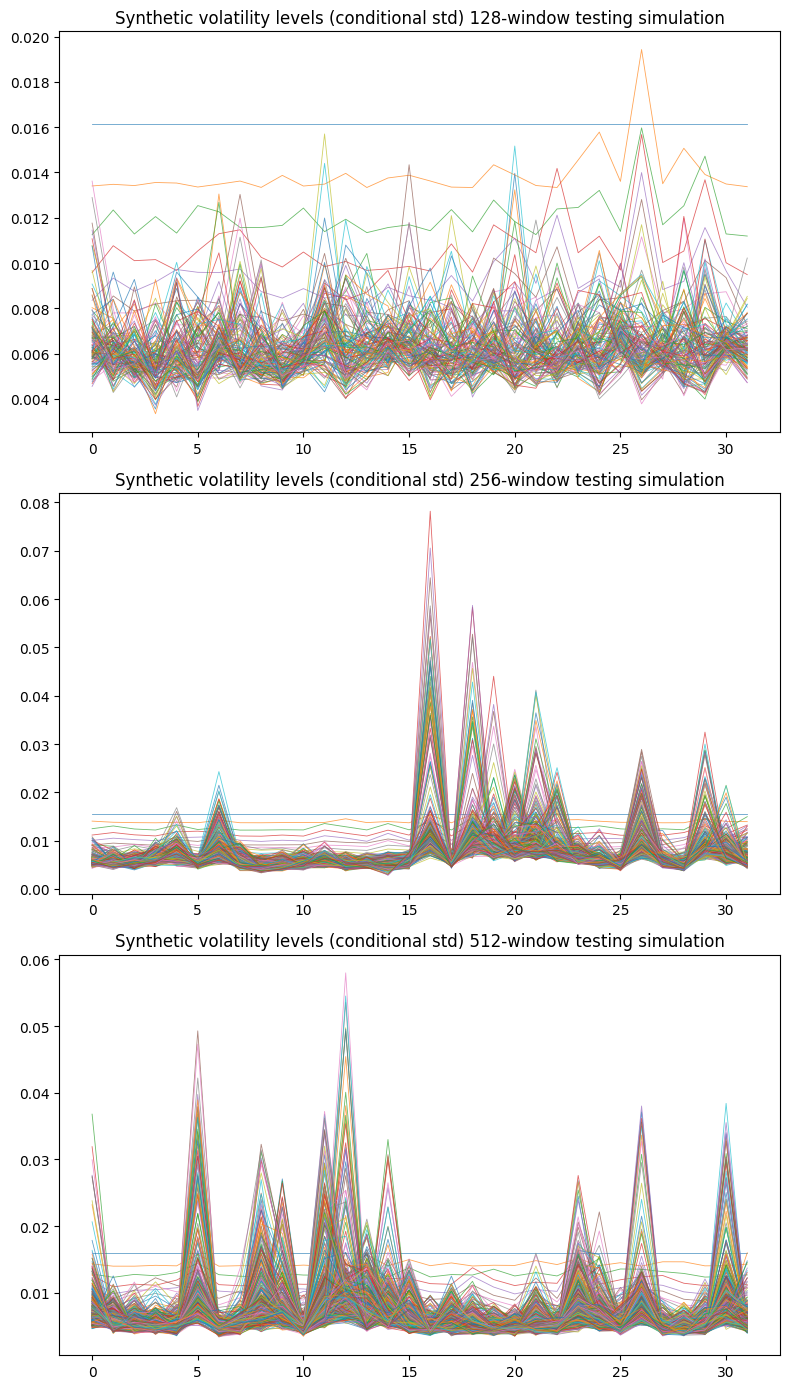

In [40]:
fig, ax = plt.subplots(3, figsize=(8,14))

ax[0].set_title("Synthetic volatility levels (conditional std) 128-window testing simulation")
ax[1].set_title("Synthetic volatility levels (conditional std) 256-window testing simulation")
ax[2].set_title("Synthetic volatility levels (conditional std) 512-window testing simulation")

ax[0].plot(syn_preds_windows_128, linewidth=0.6, alpha=0.7)
ax[1].plot(syn_preds_windows_256, linewidth=0.6, alpha=0.7)
ax[2].plot(syn_preds_windows_512, linewidth=0.6, alpha=0.7)

plt.tight_layout()
plt.show()

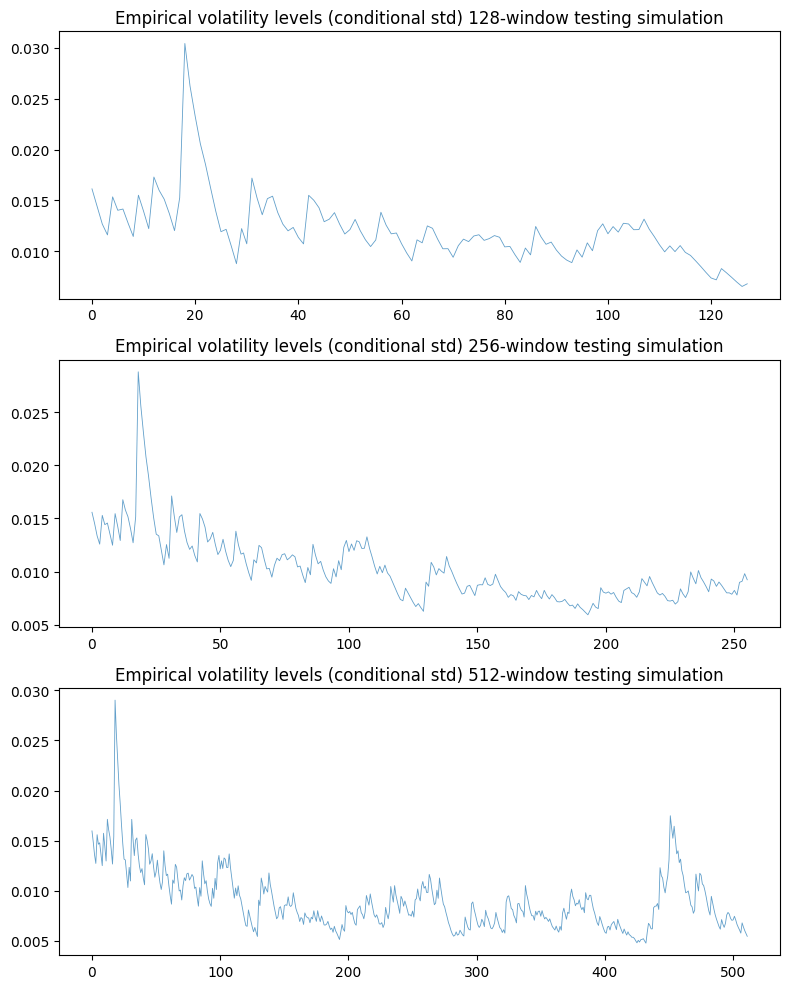

In [41]:
fig, ax = plt.subplots(3, figsize=(8,10))

ax[0].set_title("Empirical volatility levels (conditional std) 128-window testing simulation")
ax[1].set_title("Empirical volatility levels (conditional std) 256-window testing simulation")
ax[2].set_title("Empirical volatility levels (conditional std) 512-window testing simulation")

ax[0].plot(emp_preds_128, linewidth=0.6, alpha=0.7)
ax[1].plot(emp_preds_256, linewidth=0.6, alpha=0.7)
ax[2].plot(emp_preds_512, linewidth=0.6, alpha=0.7)

plt.tight_layout()
plt.show()

In [42]:
# model fitting
res_mc = arch_model(train_snp500 * 100, vol="Garch", p=1, q=1).fit(disp="off")

In [43]:
# monte carlo sim
sim_paths_128 = []
sim_paths_256 = []
sim_paths_512 = []

for _ in range(32):
  sim_128 = res_mc.model.simulate(res_mc.params, nobs=128)
  sim_256 = res_mc.model.simulate(res_mc.params, nobs=256)
  sim_512 = res_mc.model.simulate(res_mc.params, nobs=512)

  sim_paths_128.append(sim_128["data"].values)
  sim_paths_256.append(sim_256["data"].values)
  sim_paths_512.append(sim_512["data"].values)

In [44]:
mc_preds_128 = []
mc_losses_128 = []
 
for i in range(32):
  fake_test = sim_paths_128[i] # still scaled
  preds, losses = one_step_rolling_forecast(latest_emp_window_128 * 100, fake_test)
  mc_preds_128.append(preds)
  mc_losses_128.append(losses)

In [45]:
mc_preds_256 = []
mc_losses_256 = []

for i in range(32):
  fake_test = sim_paths_256[i]
  preds, losses = one_step_rolling_forecast(latest_emp_window_256 * 100, fake_test)
  mc_preds_256.append(preds)
  mc_losses_256.append(losses)

In [46]:
mc_preds_512 = []
mc_losses_512 = []

for i in range(32):
  fake_test = sim_paths_512[i]
  preds, losses = one_step_rolling_forecast(latest_emp_window_512 * 100, fake_test)
  mc_preds_512.append(preds)
  mc_losses_512.append(losses)

In [47]:
# scaled back
mc_preds_128 = np.array(mc_preds_128) / 100
mc_preds_256 = np.array(mc_preds_256) / 100
mc_preds_512 = np.array(mc_preds_512) / 100

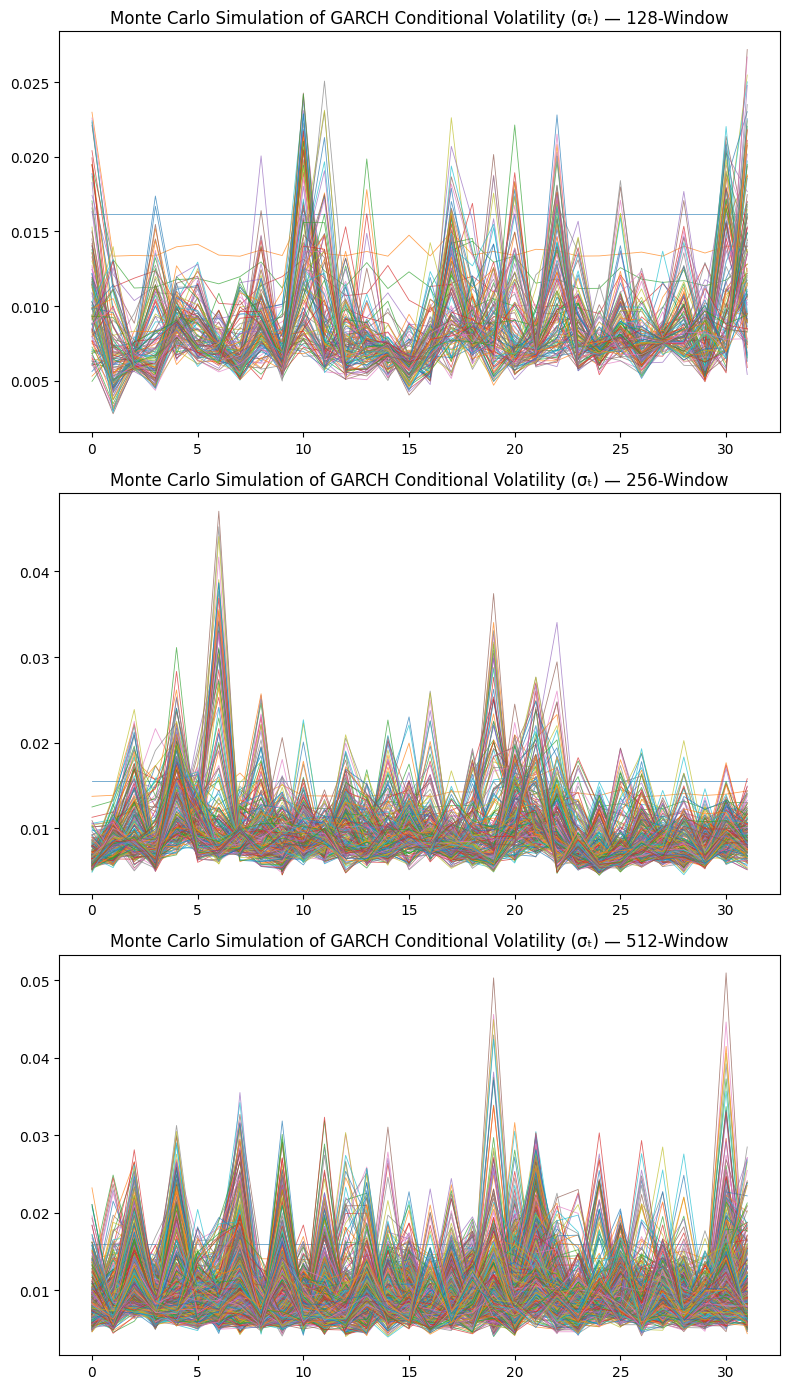

In [48]:
fig, ax = plt.subplots(3, figsize=(8,14))

ax[0].set_title("Monte Carlo Simulation of GARCH Conditional Volatility (σₜ) — 128-Window")
ax[1].set_title("Monte Carlo Simulation of GARCH Conditional Volatility (σₜ) — 256-Window")
ax[2].set_title("Monte Carlo Simulation of GARCH Conditional Volatility (σₜ) — 512-Window")

ax[0].plot(mc_preds_128, linewidth=0.6, alpha=0.7)
ax[1].plot(mc_preds_256, linewidth=0.6, alpha=0.7)
ax[2].plot(mc_preds_512, linewidth=0.6, alpha=0.7)

plt.tight_layout()
plt.show()

### Loss evaluation

In [51]:
emp_losses_128 = np.array(emp_losses_128)
emp_losses_256 = np.array(emp_losses_256)
emp_losses_512 = np.array(emp_losses_512)

syn_losses_windows_128 = np.array(syn_losses_windows_128)
syn_losses_windows_256 = np.array(syn_losses_windows_256)
syn_losses_windows_512 = np.array(syn_losses_windows_512)

mc_losses_128 = np.array(mc_losses_128)
mc_losses_256 = np.array(mc_losses_256)
mc_losses_512 = np.array(mc_losses_512)

print("QLIKE LOSS EVALUATION")
print("Empirical Losses:")
print(f"128 -> mean: {emp_losses_128.mean():.3f}, std: {emp_losses_128.std():.3f}, min: {emp_losses_128.min():.3f}, max: {emp_losses_128.max():.3f}, median: {np.median(emp_losses_128):.3f}")
print(f"256 -> mean: {emp_losses_256.mean():.3f}, std: {emp_losses_256.std():.3f}, min: {emp_losses_256.min():.3f}, max: {emp_losses_256.max():.3f}, median: {np.median(emp_losses_256):.3f}")
print(f"512 -> mean: {emp_losses_512.mean():.3f}, std: {emp_losses_512.std():.3f}, min: {emp_losses_512.min():.3f}, max: {emp_losses_512.max():.3f}, median: {np.median(emp_losses_512):.3f}")

print("\nSynthetic Losses:")
print(f"128 -> mean: {syn_losses_windows_128.mean():.3f}, std: {syn_losses_windows_128.std():.3f}, min: {syn_losses_windows_128.min():.3f}, max: {syn_losses_windows_128.max():.3f}, median: {np.median(syn_losses_windows_128):.3f}")
print(f"256 -> mean: {syn_losses_windows_256.mean():.3f}, std: {syn_losses_windows_256.std():.3f}, min: {syn_losses_windows_256.min():.3f}, max: {syn_losses_windows_256.max():.3f}, median: {np.median(syn_losses_windows_256):.3f}")
print(f"512 -> mean: {syn_losses_windows_512.mean():.3f}, std: {syn_losses_windows_512.std():.3f}, min: {syn_losses_windows_512.min():.3f}, max: {syn_losses_windows_512.max():.3f}, median: {np.median(syn_losses_windows_512):.3f}")

print("\nMonte Carlo Losses:")
print(f"128 -> mean: {mc_losses_128.mean():.3f}, std: {mc_losses_128.std():.3f}, min: {mc_losses_128.min():.3f}, max: {mc_losses_128.max():.3f}, median: {np.median(mc_losses_128):.3f}")
print(f"256 -> mean: {mc_losses_256.mean():.3f}, std: {mc_losses_256.std():.3f}, min: {mc_losses_256.min():.3f}, max: {mc_losses_256.max():.3f}, median: {np.median(mc_losses_256):.3f}")
print(f"512 -> mean: {mc_losses_512.mean():.3f}, std: {mc_losses_512.std():.3f}, min: {mc_losses_512.min():.3f}, max: {mc_losses_512.max():.3f}, median: {np.median(mc_losses_512):.3f}")

QLIKE LOSS EVALUATION
Empirical Losses:
128 -> mean: 1.355, std: 1.696, min: -0.750, max: 13.327, median: 0.956
256 -> mean: 0.908, std: 1.483, min: -0.968, max: 13.529, median: 0.527
512 -> mean: 0.677, std: 1.551, min: -1.380, max: 13.136, median: 0.276

Synthetic Losses:
128 -> mean: -0.142, std: 1.408, min: -2.067, max: 16.566, median: -0.523
256 -> mean: 0.022, std: 1.641, min: -2.400, max: 26.040, median: -0.391
512 -> mean: -0.100, std: 1.729, min: -2.126, max: 44.932, median: -0.521

Monte Carlo Losses:
128 -> mean: 0.626, std: 1.612, min: -2.291, max: 12.950, median: 0.232
256 -> mean: 0.710, std: 1.462, min: -1.507, max: 13.134, median: 0.345
512 -> mean: 0.777, std: 1.575, min: -1.755, max: 17.085, median: 0.409
